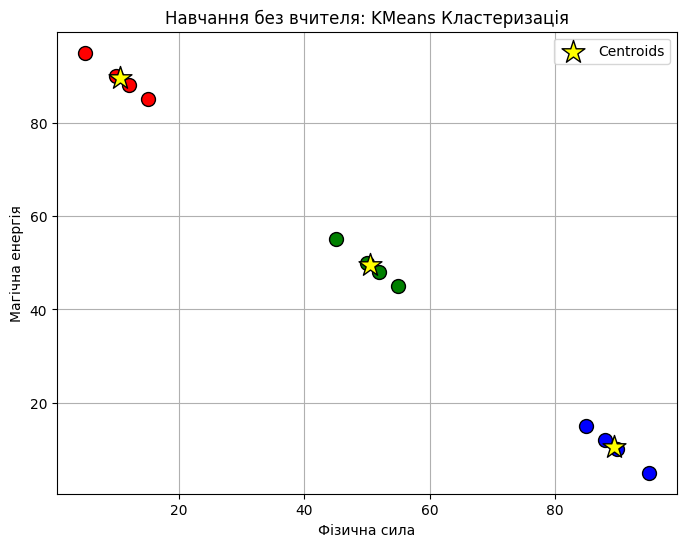

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, dbscan
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# 1. Створення набору даних (Навчання без вчителя працює з даними без міток)
# Формат: [Фізична сила, Магічна енергія] (оцінки від 1 до 100)
# Уявімо, що це характеристики різних ігрових або комікс-персонажів.
X = np.array([
    [90, 10], [85, 15], [95, 5],   # Сильні фізично, мало магії (Танки/Бійці)
    [10, 90], [15, 85], [5, 95],   # Слабкі фізично, сильні в магії (Маги/Еспери)
    [50, 50], [55, 45], [45, 55],  # Збалансовані персонажі
    [88, 12], [12, 88], [52, 48]   # Додаткові точки для реалістичності
])

#2. Ініціалізація та навчання моделі KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # розділяємо на 3 кластери

#3. Навчання моделі на даних (без міток)
kmeans.fit(X)

#4. Отримання результатів кластеризації
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

#5. Візуалізація результатів
plt.figure(figsize=(8, 6))
colors = ["red", "blue", "green"]

for i in range(len(X)):
    plt.scatter(X[i][0], X[i][1], color=colors[labels[i]], s=100, edgecolors='black')

# Відображення центрів кластерів (центроїдів)
plt.scatter(centroids[:, 0], centroids[:, 1], color='yellow', marker = "*", s=300, edgecolors='black', label='Centroids')

plt.title("Навчання без вчителя: KMeans Кластеризація")
plt.xlabel("Фізична сила")
plt.ylabel("Магічна енергія")
plt.legend()
plt.grid()
# plt.savefig("kmeans_clustering_test.png")  # Збереження графіка у файл
plt.show()

#6. Тестування на нових даних (наприклад, новий персонаж з характеристиками [70, 30])
new_character = np.array([[70, 30]])
predicted_cluster = kmeans.predict(new_character)
# print(f"Новий персонаж з характеристиками [70, 30] належить до кластера: {predicted_cluster[0]}")

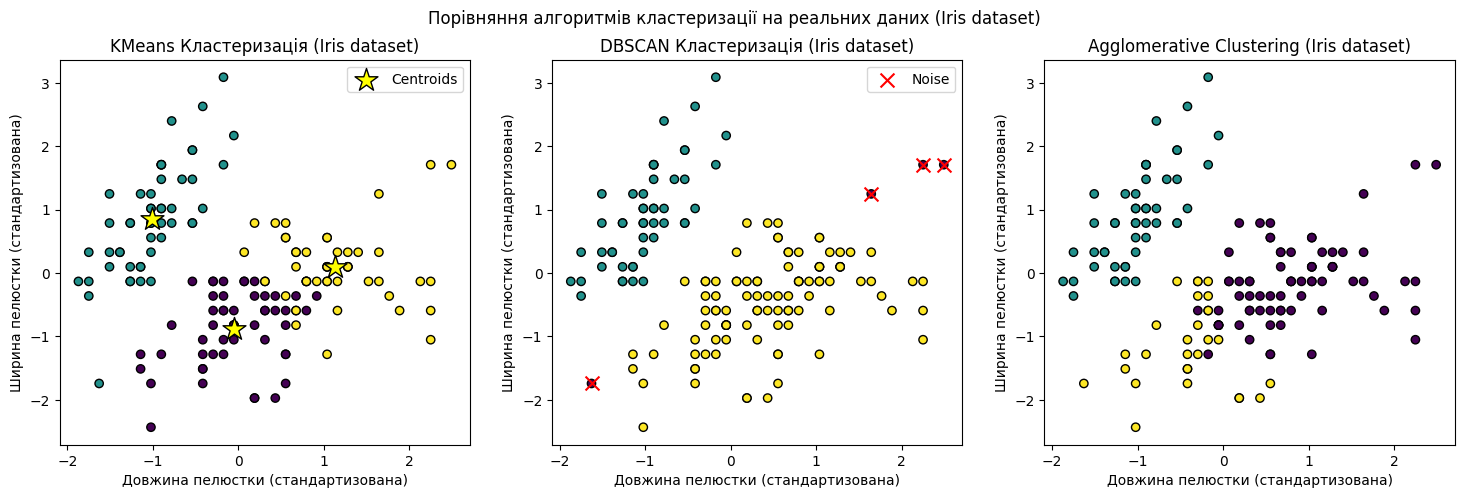

In [5]:
# print("Завантажюємо реальні дані (Iris dataset) для порівняння з KMeans...")
iris = load_iris()
X_real = iris.data  # Використовуємо лише дві ознаки для візуалізації
# print(X_real)

# Стандартизація даних (збільшує ефективність кластеризації)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_real)

# Навчання KMeans на реальних даних
kmeans_real = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_real.fit(X_scaled)
centroids_real = kmeans_real.cluster_centers_
# print("Кластери на реальних даних (Iris dataset):", kmeans_real.labels_)

dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
# print("Кластери на реальних даних (DBSCAN):", labels_dbscan)

agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_scaled)
# print("Кластери на реальних даних (Agglomerative Clustering):", labels_agglo)

# Візуалізація результатів кластеризації на реальних даних
fix, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_real.labels_, cmap='viridis', edgecolors='black')
axes[0].set_title("KMeans Кластеризація (Iris dataset)")
axes[0].set_xlabel("Довжина пелюстки (стандартизована)")
axes[0].set_ylabel("Ширина пелюстки (стандартизована)")
# центроїди
axes[0].scatter(centroids_real[:, 0], centroids_real[:, 1], color='yellow', marker='*', s=300, edgecolors='black', label='Centroids')
axes[0].legend()


# DBSCAN
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap='viridis', edgecolors='black')
# відображення шумів (якщо є)
axes[1].scatter(X_scaled[labels_dbscan == -1, 0], X_scaled[labels_dbscan == -1, 1], color='red', marker='x', s=100, label='Noise')
axes[1].set_title("DBSCAN Кластеризація (Iris dataset)")
axes[1].set_xlabel("Довжина пелюстки (стандартизована)")
axes[1].set_ylabel("Ширина пелюстки (стандартизована)")
unique_labels_dbscan = set(labels_dbscan)
axes[1].legend()

# Agglomerative Clustering
axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agglo, cmap='viridis', edgecolors='black')
axes[2].set_title("Agglomerative Clustering (Iris dataset)")
axes[2].set_xlabel("Довжина пелюстки (стандартизована)")
axes[2].set_ylabel("Ширина пелюстки (стандартизована)")


plt.suptitle("Порівняння алгоритмів кластеризації на реальних даних (Iris dataset)")
# plt.tight_layout()
# plt.savefig("clustering_comparison_iris.png")  # Збереження графіка у файл
# plt.grid()
# plt.savefig("clustering_comparison_iris_4params.png")  # Збереження графіка у файл
plt.show()